In [224]:
import os
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_ionq import IonQProvider

In [226]:
X = np.linspace(0, 2*np.pi, 20, requires_grad=False)
X_test = np.linspace(0.2, 2*np.pi + 0.2, 20, requires_grad=False)

def target(x):
    return 0.5*np.sin(x) + 0.5*np.sin(2*x)


Y_train = target(X)
Y_test  = target(X_test)

In [ ]:
n_wires = 2
dev_parallel = qml.device("lightning.qubit", wires=n_wires)
dev_serial   = qml.device("lightning.qubit", wires=1)

In [227]:
@qml.qnode(dev_serial)
def circuit_serial(x, params):
    for k in range(params.shape[0]):
        qml.RY(x, wires=0)
        qml.Rot(params[k, 0], params[k, 1], params[k, 2], wires=0)
    return qml.expval(qml.PauliX(0))

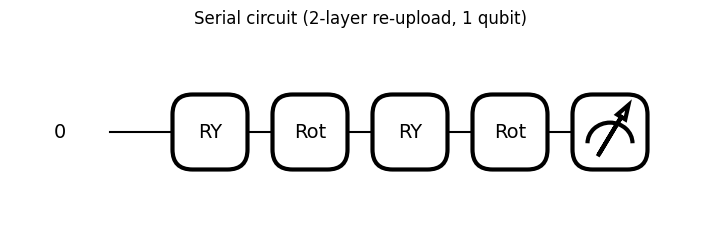

In [242]:

x0 = 0.3
params_serial_vis = np.zeros((2, 3), requires_grad=False)  # 2 re-upload layers

fig, ax = qml.draw_mpl(circuit_serial)(x0, params_serial_vis)
ax.set_title("Serial circuit (2-layer re-upload, 1 qubit)")
plt.show()


In [228]:
def make_parallel_qnode(entangler: str):
    @qml.qnode(dev_parallel)
    def circuit_parallel(x, params):
        for w in range(n_wires):
            qml.RY(x, wires=w)

        if entangler == "CNOT":
            qml.CNOT(wires=[0, 1])
        elif entangler == "CZ":
            qml.CZ(wires=[0, 1])
        elif entangler == "IsingXX":
            qml.IsingXX(0.7, wires=[0, 1])  # fixed angle
        else:
            raise ValueError(f"Unknown entangler: {entangler}")

        for w in range(n_wires):
            qml.Rot(params[w, 0], params[w, 1], params[w, 2], wires=w)

        # return both; we’ll average outside
        return qml.expval(qml.PauliX(0)), qml.expval(qml.PauliX(1))

    return circuit_parallel

circuit_parallel_cnot    = make_parallel_qnode("CNOT")
circuit_parallel_cz      = make_parallel_qnode("CZ")
circuit_parallel_isingxx = make_parallel_qnode("IsingXX")

/var/folders/rn/51w2pjhj1kqdh6yq8s18zh440000gq/T/ipykernel_49299/3768836462.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


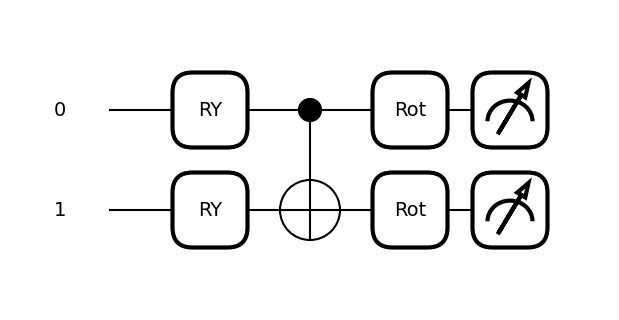

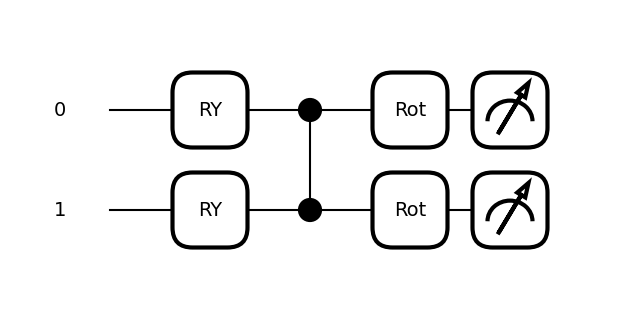

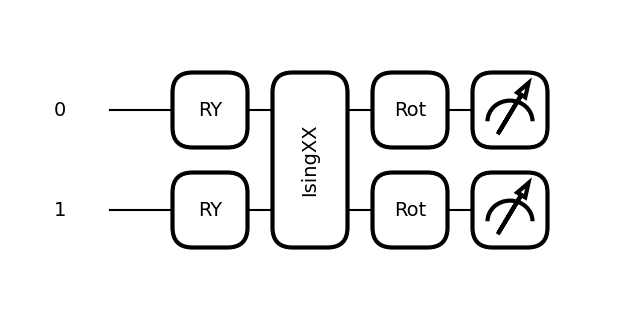

In [241]:


x0 = 0.3
params0 = np.zeros((n_wires, 3), requires_grad=False)

circuits = [
    ("Parallel + CNOT", circuit_parallel_cnot),
    ("Parallel + CZ", circuit_parallel_cz),
    ("Parallel + IsingXX(0.7)", circuit_parallel_isingxx),
]



for ax, (title, circ) in zip(axes, circuits):
    qml.drawer.draw_mpl(circ, ax=ax)(x0, params0)
    ax.set_title(title)

plt.tight_layout()
plt.show()


In [229]:

def loss(y, yhat):
    return np.mean((y - yhat) ** 2)

def eval_circuit(circuit_fn, x, params):
    out = circuit_fn(x, params)
    if isinstance(out, (tuple, list)):
        return np.mean(np.array(out))
    return out

def make_cost(circuit_fn, X, Y):
    def cost(params):
        preds = np.array([eval_circuit(circuit_fn, x, params) for x in X])
        return loss(Y, preds)
    return cost

def predict(circuit_fn, X_in, params):
    return np.array([eval_circuit(circuit_fn, x, params) for x in X_in])

In [230]:
def train(circuit_fn, params_init, X, Y, n_iter=200, stepsize=0.1, print_every=20, tag=""):
    opt = qml.GradientDescentOptimizer(stepsize=stepsize)
    cost_fn = make_cost(circuit_fn, X, Y)

    params = np.array(params_init, requires_grad=True)
    hist = np.zeros((n_iter,), requires_grad=False)

    for it in range(n_iter):
        params, _ = opt.step_and_cost(cost_fn, params)
        c = cost_fn(params)
        hist[it] = c
        if (print_every is not None) and (it % print_every == 0):
            print(f"[{tag}] step {it:>4} | cost = {c:.6f}")

    return params, hist


In [ ]:
params_serial_init = np.array([[0.1, 0.1, 0.1],
                              [0.1, 0.1, 0.1]])   # (2,3)

params_parallel_init = np.array([[0.1, 0.1, 0.1],
                                [0.1, 0.1, 0.1]]) # (2,3)

In [231]:
# Train serial

params_serial_tr, hist_serial = train(
    circuit_serial, params_serial_init, X, Y_train,
    n_iter=200, stepsize=0.1, print_every=20, tag="serial"
)


# Train parallel (3 variants)

parallel_variants = {
    "Parallel+CNOT":    circuit_parallel_cnot,
    "Parallel+CZ":      circuit_parallel_cz,
    "Parallel+IsingXX": circuit_parallel_isingxx,
}

trained_parallel = {}
hist_parallel = {}
pred_parallel_test = {}

for name, circ in parallel_variants.items():
    p_tr, h_tr = train(
        circ, params_parallel_init, X, Y_train,
        n_iter=400, stepsize=0.05, print_every=20, tag=name
    )
    trained_parallel[name] = p_tr
    hist_parallel[name] = h_tr
    pred_parallel_test[name] = predict(circ, X_test, p_tr)


[serial] step    0 | cost = 0.251522
[serial] step   20 | cost = 0.095366
[serial] step   40 | cost = 0.000105
[serial] step   60 | cost = 0.000005
[serial] step   80 | cost = 0.000001
[serial] step  100 | cost = 0.000000
[serial] step  120 | cost = 0.000000
[serial] step  140 | cost = 0.000000
[serial] step  160 | cost = 0.000000
[serial] step  180 | cost = 0.000000
[Parallel+CNOT] step    0 | cost = 0.211349
[Parallel+CNOT] step   20 | cost = 0.202537
[Parallel+CNOT] step   40 | cost = 0.193059
[Parallel+CNOT] step   60 | cost = 0.181483
[Parallel+CNOT] step   80 | cost = 0.167625
[Parallel+CNOT] step  100 | cost = 0.153232
[Parallel+CNOT] step  120 | cost = 0.140932
[Parallel+CNOT] step  140 | cost = 0.132172
[Parallel+CNOT] step  160 | cost = 0.126698
[Parallel+CNOT] step  180 | cost = 0.123509
[Parallel+CNOT] step  200 | cost = 0.121689
[Parallel+CNOT] step  220 | cost = 0.120637
[Parallel+CNOT] step  240 | cost = 0.120008
[Parallel+CNOT] step  260 | cost = 0.119616
[Parallel+CNOT

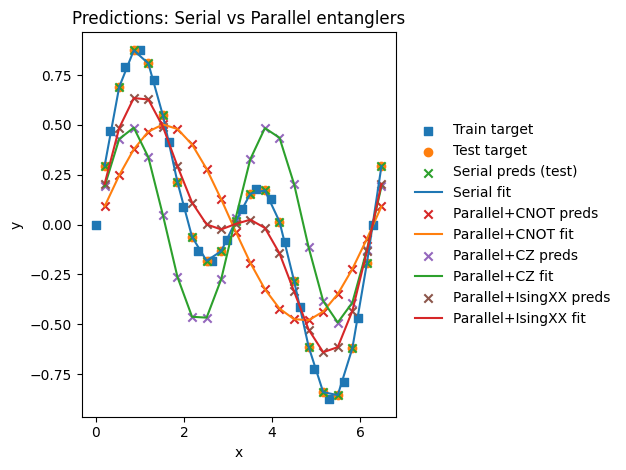

In [238]:
plt.figure()

# sort X_test for clean line plots
idx = np.argsort(X_test)
X_test_sorted = X_test[idx]
Y_test_sorted = Y_test[idx]

# targets
plt.scatter(X, Y_train, marker="s", label="Train target")
plt.scatter(X_test, Y_test, marker="o", label="Test target")
#plt.plot(X_test_sorted, Y_test_sorted, linestyle="--", alpha=0.6, label="Target (test)")

# serial predictions
pred_serial_sorted = pred_serial_test[idx]
plt.scatter(X_test, pred_serial_test, marker="x", label="Serial preds (test)")
plt.plot(X_test_sorted, pred_serial_sorted, label="Serial fit")

# parallel predictions
for name in parallel_variants.keys():
    preds = pred_parallel_test[name]
    preds_sorted = preds[idx]
    plt.scatter(X_test, preds, marker="x", label=f"{name} preds")
    plt.plot(X_test_sorted, preds_sorted, label=f"{name} fit")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Predictions: Serial vs Parallel entanglers")

# legend outside
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()


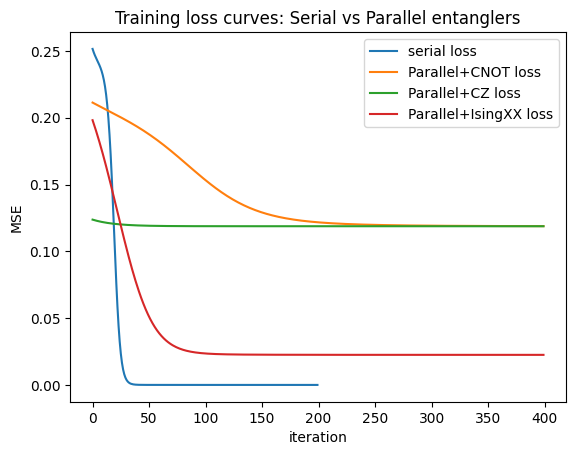

In [236]:

# Plot: loss curves 

plt.figure()
plt.plot(hist_serial, label="serial loss")

for name, h in hist_parallel.items():
    plt.plot(h, label=f"{name} loss")

plt.xlabel("iteration"); plt.ylabel("MSE")
plt.title("Training loss curves: Serial vs Parallel entanglers")
plt.legend()
plt.show()